# Critical Reproduction of a Phishing Website Detection Tutorial

**Student:** Layan Awawde  
**Course:** Data Science in Cybersecurity  
**Selected blog post:** Nicolas Papernot, “Detecting phishing websites using a decision tree” (Medium, 2016)  
**Original implementation:** `https://github.com/npapernot/phishing-detection`  
**Dataset:** UCI Phishing Websites, DOI `10.24432/C51W2X`

This notebook is fully executable from either the repository root or the `notebooks/` directory.

## Executive Summary

This project critically reproduces a 2016 tutorial that claims approximately 90.5% accuracy for a decision-tree phishing detector. The numerical claim can be reproduced on the **current** repository file only when the script trains on the first 2,000 rows and silently tests on all remaining 9,055 rows. The source documentation, however, says that the dataset contains 2,456 websites and that only 456 are tested. Running the same first-2,000 split on the first 2,456 rows of the current file produces about 96%, not 90.5%. The current code also multiplies accuracy by 100 while the README shows a decimal output, and it does not set a random seed.

A second, more serious documentation issue concerns the target meaning. The tutorial prose says `1 = phishing` and `-1 = legitimate`, while the established UCI convention for this dataset is `1 = legitimate` and `-1 = phishing`. This notebook therefore converts the original `Result` column into a clearly named binary target, `phishing = 1` when `Result = -1`, so that phishing-specific precision, recall, F-scores, and error costs are interpreted correctly.

The raw table contains 11,055 rows, 5,206 repeated exact rows, and 64 unique feature vectors that appear with contradictory labels. To avoid direct duplicate leakage and impossible label contradictions, the primary experiment retains one row per unique, consistently labeled feature vector, leaving 5,721 rows. Logistic Regression, a controlled Decision Tree, and Random Forest are evaluated using a stratified 80/20 holdout and 5-fold stratified cross-validation. The Random Forest performs best, with holdout F1 around 0.97 and cross-validated F1 around 0.96. A reduced 27-feature version performs similarly, showing that three highly redundant variables can be removed without harming predictive performance in this split.

The tutorial is suitable as a small teaching example, but its current evidence is insufficient for production deployment. It lacks reliable documentation, a complete feature-extraction pipeline, duplicate-aware evaluation, temporal metadata, external validation, threshold selection based on operational cost, and defenses against concept drift or adversarial manipulation.

## 1. Setup and reproducibility

A fixed random seed is used for every stochastic experiment. The helper functions are short and located in `src/`. Figures and result tables are generated by this notebook rather than inserted manually.

In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.stats import spearmanr

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay,
    confusion_matrix, f1_score, fbeta_score, precision_score, recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier


def find_project_root() -> Path:
    for candidate in [Path.cwd(), Path.cwd().parent]:
        if (candidate / "data" / "dataset.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate data/dataset.csv from the current directory.")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_utils import FEATURE_NAMES, load_dataset, unique_consistent_feature_vectors
from src.evaluate import evaluate_classifier, positive_probability

DATA_PATH = PROJECT_ROOT / "data" / "dataset.csv"
FIGURE_DIR = PROJECT_ROOT / "figures"
RESULT_DIR = PROJECT_ROOT / "results"
FIGURE_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42
print("Project root:", PROJECT_ROOT)

Project root: /mnt/data/phishing_detection_project_v2


## 2. Data loading and structural inspection

The source CSV is headerless, so names are taken from the original repository's feature list. The index is a default `RangeIndex` and carries no semantic identifier. That is acceptable for tabular modeling, but the absence of URL, domain, campaign, and timestamp identifiers prevents campaign-aware or temporal splitting.

In [2]:
data = load_dataset(DATA_PATH)
print("Shape:", data.shape)
print("Index type:", type(data.index).__name__, "| Index name:", data.index.name)
print("Feature dtypes:")
display(data.dtypes.value_counts().rename("number_of_columns").to_frame())
display(data.head())

Shape: (11055, 32)
Index type: RangeIndex | Index name: None
Feature dtypes:


,number_of_columns
int64,32


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,port,HTTPS_token,Request_URL,URL_of_Anchor,Links_in_tags,SFH,Submitting_to_email,Abnormal_URL,Redirect,on_mouseover,RightClick,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result,phishing
0,-1,1,1,1,-1,-1,-1,-1,-1,1,1,-1,1,-1,1,-1,-1,-1,0,1,1,1,1,-1,-1,-1,-1,1,1,-1,-1,1
1,1,1,1,1,1,-1,0,1,-1,1,1,-1,1,0,-1,-1,1,1,0,1,1,1,1,-1,-1,0,-1,1,1,1,-1,1
2,1,0,1,1,1,-1,-1,-1,-1,1,1,-1,1,0,-1,-1,-1,-1,0,1,1,1,1,1,-1,1,-1,1,0,-1,-1,1
3,1,0,1,1,1,-1,-1,-1,1,1,1,-1,-1,0,0,-1,1,1,0,1,1,1,1,-1,-1,1,-1,1,-1,1,-1,1
4,1,0,-1,1,1,-1,1,1,-1,1,1,1,1,0,0,-1,1,1,0,-1,1,-1,1,-1,-1,0,-1,1,1,1,1,0


In [3]:
allowed_feature_values = {-1, 0, 1}
invalid_values = {
    feature: sorted(set(data[feature].unique()) - allowed_feature_values)
    for feature in FEATURE_NAMES
    if set(data[feature].unique()) - allowed_feature_values
}

quality_summary = pd.Series({
    "rows": len(data),
    "predictors": len(FEATURE_NAMES),
    "missing_cells": int(data.isna().sum().sum()),
    "constant_predictors": int((data[FEATURE_NAMES].nunique() == 1).sum()),
    "exact_duplicate_repetitions": int(data.duplicated(FEATURE_NAMES + ["Result"]).sum()),
    "feature_vector_duplicate_repetitions": int(data.duplicated(FEATURE_NAMES).sum()),
})
print("Invalid predictor codes:", invalid_values)
display(quality_summary.to_frame("value"))

Invalid predictor codes: {}


,value
rows,11055
predictors,30
missing_cells,0
constant_predictors,0
exact_duplicate_repetitions,5206
feature_vector_duplicate_repetitions,5270


### Target-label audit

The tutorial prose states that `1` denotes phishing and `-1` denotes legitimate. The UCI convention used by the underlying dataset literature is the opposite: `1 = legitimate` and `-1 = phishing`. The project therefore preserves the original `Result` field but creates `phishing = 1` when `Result = -1`. This correction does not change accuracy, but it **does** change which class is treated as positive and therefore changes the meaning of precision, recall, F-scores, false positives, and false negatives.

In [4]:
class_table = pd.DataFrame({
    "count": data["Result"].value_counts().sort_index(),
    "percentage": data["Result"].value_counts(normalize=True).sort_index() * 100,
    "interpretation": ["Phishing", "Legitimate"],
})
display(class_table.style.format({"percentage": "{:.2f}%"}))
print("Raw phishing prevalence:", f"{data['phishing'].mean():.2%}")

,count,percentage,interpretation
Result,,,
-1,4898,44.31%,Phishing
1,6157,55.69%,Legitimate


Raw phishing prevalence: 44.31%


## 3. Exploratory Data Analysis

### 3.1 Missing values, single-valued fields, and rare values

There are no missing cells and no constant predictors. Since every predictor is a bounded binary or ternary indicator, z-scores, IQR fences, and continuous boxplots would not identify meaningful outliers. The relevant checks are invalid codes, rare categories, near-constant fields, duplicate vectors, and contradictory labels.

In [5]:
feature_profile_rows = []
for feature in FEATURE_NAMES:
    counts = data[feature].value_counts(dropna=False)
    feature_profile_rows.append({
        "feature": feature,
        "unique_values": data[feature].nunique(),
        "mode": counts.index[0],
        "mode_coverage": counts.iloc[0] / len(data),
        "rarest_value_count": counts.iloc[-1],
    })
feature_profile = pd.DataFrame(feature_profile_rows).sort_values("mode_coverage", ascending=False)
display(feature_profile.head(12).style.format({"mode_coverage": "{:.2%}"}))
feature_profile.to_csv(RESULT_DIR / "feature_profile.csv", index=False)

,feature,unique_values,mode,mode_coverage,rarest_value_count
20,RightClick,2,1,95.69%,476
22,Iframe,2,1,90.85%,1012
18,Redirect,2,0,88.43%,1279
19,on_mouseover,2,1,88.10%,1315
4,double_slash_redirecting,2,1,87.07%,1429
2,Shortining_Service,2,1,86.94%,1444
5,Prefix_Suffix,2,-1,86.75%,1465
10,port,2,1,86.41%,1502
27,Google_Index,2,1,86.08%,1539
29,Statistical_report,2,1,85.98%,1550


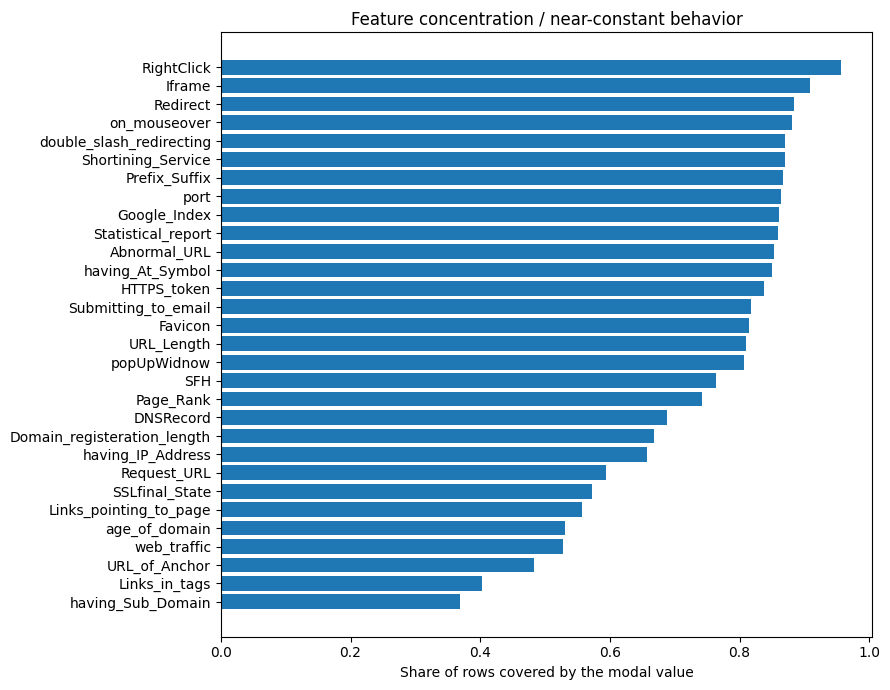

In [6]:
plt.figure(figsize=(9, 7))
plot_data = feature_profile.sort_values("mode_coverage")
plt.barh(plot_data["feature"], plot_data["mode_coverage"])
plt.xlabel("Share of rows covered by the modal value")
plt.title("Feature concentration / near-constant behavior")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "feature_mode_coverage.png", dpi=180)
plt.show()

`RightClick` is highly concentrated, so it contributes little variation by itself. A high modal share does not automatically make a feature useless, but it motivates checking importance and stability rather than assuming every indicator contributes equally.

### 3.2 Class prevalence and real-world meaning

The raw dataset contains about 44% phishing observations, which is only mildly imbalanced and is far more phishing-heavy than many production environments. The selected source does not discuss this prevalence mismatch or its effect on alert volume. No oversampling or SMOTE is used because the training data are not severely imbalanced, and synthetic interpolation of discrete security rules would be difficult to justify. Instead, stratification and metrics beyond accuracy are used.

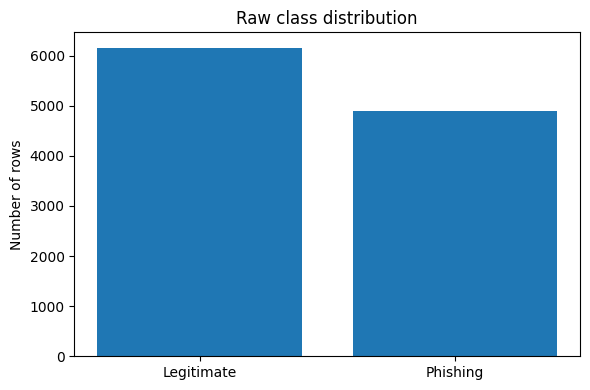

In [7]:
class_counts = data["phishing"].map({0: "Legitimate", 1: "Phishing"}).value_counts()
plt.figure(figsize=(6, 4))
plt.bar(class_counts.index, class_counts.values)
plt.ylabel("Number of rows")
plt.title("Raw class distribution")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "class_distribution_raw.png", dpi=180)
plt.show()

### 3.3 Crosstab analysis

`SSLfinal_State` is shown because it has a clear cybersecurity interpretation and a strong association with the target. Row-normalized percentages answer: given an SSL-state code, what share of records belongs to each class?

In [8]:
ssl_crosstab = pd.crosstab(
    data["SSLfinal_State"],
    data["phishing"].map({0: "Legitimate", 1: "Phishing"}),
    normalize="index",
)
display(ssl_crosstab.style.format("{:.2%}"))

phishing,Legitimate,Phishing
SSLfinal_State,,
-1,14.23%,85.77%
0,1.80%,98.20%
1,88.93%,11.07%


### 3.4 Correlation methodology

Spearman's rank correlation is used for feature-feature redundancy because the predictors are ordered/discrete risk indicators and linear-Gaussian assumptions are inappropriate. Spearman correlation is Pearson correlation applied to ranks:

\[
\rho_s = \mathrm{corr}(\mathrm{rank}(X),\mathrm{rank}(Y)).
\]

It detects monotonic association, is less sensitive to extreme values than Pearson, and does not require normality. Its limitations are that it does not capture every nonlinear relationship and can be influenced by many tied ranks, which are common in binary/ternary data. Kendall correlation would also be defensible, but with more than 5,000 observations Spearman is computationally simpler and directly supports a redundancy heatmap.

For feature-target association, both effect size and p-value are reported. With thousands of rows, very small effects can be statistically significant, so practical interpretation focuses on the magnitude of \(|\rho_s|\), not p-value alone.

In [9]:
clean_data, conflict_groups = unique_consistent_feature_vectors(data)
clean_feature_correlation = clean_data[FEATURE_NAMES].corr(method="spearman")

pairs = []
for left_index, left in enumerate(FEATURE_NAMES):
    for right in FEATURE_NAMES[left_index + 1:]:
        rho = clean_feature_correlation.loc[left, right]
        pairs.append({"feature_1": left, "feature_2": right, "spearman_rho": rho, "abs_rho": abs(rho)})
high_correlation_pairs = pd.DataFrame(pairs).sort_values("abs_rho", ascending=False)
display(high_correlation_pairs.head(12).style.format({"spearman_rho": "{:.3f}", "abs_rho": "{:.3f}"}))
high_correlation_pairs.to_csv(RESULT_DIR / "feature_correlations.csv", index=False)

,feature_1,feature_2,spearman_rho,abs_rho
236,Favicon,popUpWidnow,0.933,0.933
58,Shortining_Service,double_slash_redirecting,0.814,0.814
225,Favicon,port,0.812,0.812
250,port,Submitting_to_email,0.784,0.784
255,port,popUpWidnow,0.754,0.754
116,double_slash_redirecting,HTTPS_token,0.735,0.735
381,on_mouseover,popUpWidnow,0.731,0.731
65,Shortining_Service,HTTPS_token,0.728,0.728
71,Shortining_Service,Abnormal_URL,0.709,0.709
234,Favicon,on_mouseover,0.690,0.690


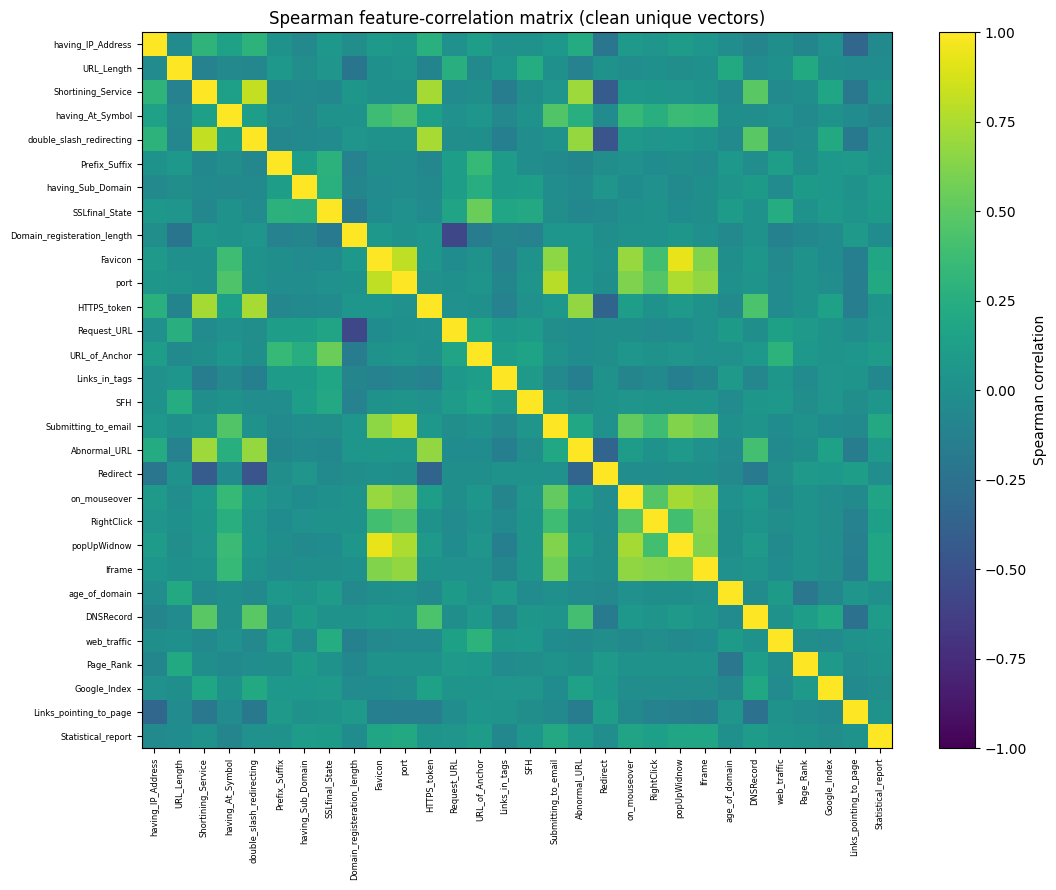

In [10]:
plt.figure(figsize=(11, 9))
plt.imshow(clean_feature_correlation, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Spearman correlation")
plt.xticks(range(len(FEATURE_NAMES)), FEATURE_NAMES, rotation=90, fontsize=6)
plt.yticks(range(len(FEATURE_NAMES)), FEATURE_NAMES, fontsize=6)
plt.title("Spearman feature-correlation matrix (clean unique vectors)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "spearman_correlation.png", dpi=200)
plt.show()

In [11]:
association_rows = []
for feature in FEATURE_NAMES:
    rho, p_value = spearmanr(clean_data[feature], clean_data["phishing"])
    association_rows.append({
        "feature": feature,
        "spearman_rho": rho,
        "p_value": p_value,
        "abs_rho": abs(rho),
        "practical_strength": (
            "strong" if abs(rho) >= 0.5 else
            "moderate" if abs(rho) >= 0.3 else
            "weak" if abs(rho) >= 0.1 else "very weak"
        ),
    })
target_associations = pd.DataFrame(association_rows).sort_values("abs_rho", ascending=False)
display(target_associations.head(15).style.format({"spearman_rho": "{:.3f}", "p_value": "{:.2e}", "abs_rho": "{:.3f}"}))
target_associations.to_csv(RESULT_DIR / "target_associations.csv", index=False)

,feature,spearman_rho,p_value,abs_rho,practical_strength
7,SSLfinal_State,-0.724,0.00e+00,0.724,strong
13,URL_of_Anchor,-0.699,0.00e+00,0.699,strong
5,Prefix_Suffix,-0.386,6.34e-203,0.386,moderate
6,having_Sub_Domain,-0.310,2.62e-127,0.310,moderate
25,web_traffic,-0.303,1.27e-121,0.303,moderate
15,SFH,-0.282,3.72e-105,0.282,weak
14,Links_in_tags,-0.252,8.88e-84,0.252,weak
12,Request_URL,-0.243,1.85e-77,0.243,weak
8,Domain_registeration_length,0.224,9.74e-66,0.224,weak
27,Google_Index,-0.120,1.02e-19,0.120,weak


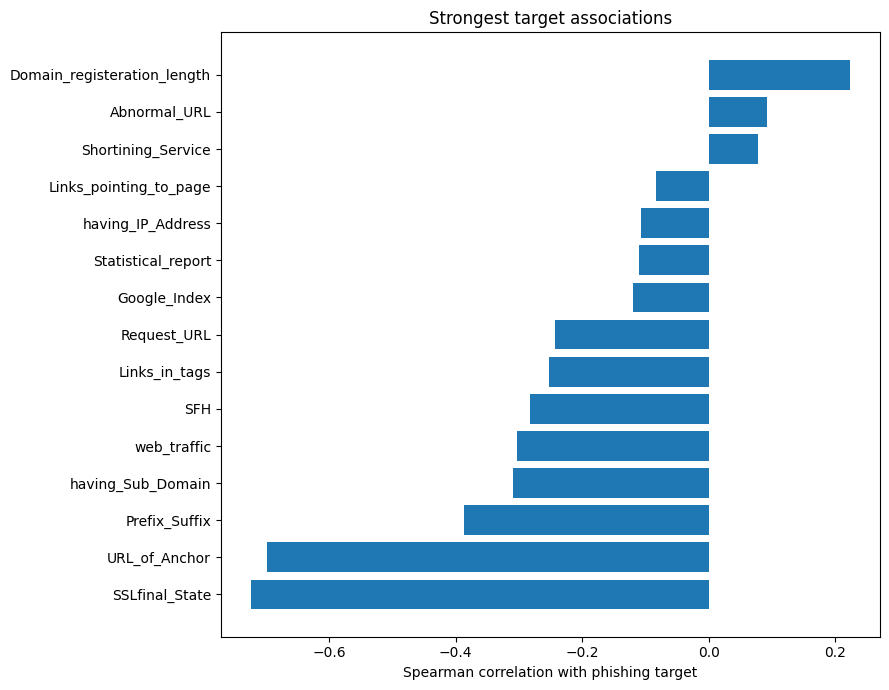

In [12]:
plt.figure(figsize=(9, 7))
plot_assoc = target_associations.head(15).sort_values("spearman_rho")
plt.barh(plot_assoc["feature"], plot_assoc["spearman_rho"])
plt.xlabel("Spearman correlation with phishing target")
plt.title("Strongest target associations")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "target_associations.png", dpi=180)
plt.show()

### 3.5 Temporal analysis

No timestamp, collection date, URL, domain, or campaign identifier is supplied. Therefore, seasonality, drift, chronological train/test separation, and campaign leakage cannot be evaluated. This absence is itself a major finding: phishing tactics and infrastructure evolve, so an IID random split cannot establish future operational performance.

## 4. Duplicate and contradictory-label analysis

Exact duplicate rows can appear in both train and test sets under random splitting. More importantly, some identical feature vectors have both labels, meaning no classifier using only these 30 predictors can classify both copies correctly. The primary evaluation therefore:

1. Groups rows by all 30 predictors.
2. Removes feature-vector groups that contain contradictory labels.
3. Keeps one row from every consistently labeled group.

This is stricter than merely dropping exact duplicate rows and prevents identical feature vectors from leaking across the split.

In [13]:
print("Raw rows:", len(data))
print("Unique feature vectors:", data[FEATURE_NAMES].drop_duplicates().shape[0])
print("Contradictory-label feature-vector groups:", len(conflict_groups))
print("Rows represented by contradictory groups:", int(conflict_groups["rows_in_group"].sum()))
print("Primary cleaned rows:", len(clean_data))

duplicate_summary = pd.DataFrame({
    "dataset": ["Raw", "Unique consistent feature vectors"],
    "rows": [len(data), len(clean_data)],
    "phishing_rows": [int(data["phishing"].sum()), int(clean_data["phishing"].sum())],
    "phishing_prevalence": [data["phishing"].mean(), clean_data["phishing"].mean()],
})
display(duplicate_summary.style.format({"phishing_prevalence": "{:.2%}"}))
duplicate_summary.to_csv(RESULT_DIR / "data_cleaning_summary.csv", index=False)
conflict_groups.to_csv(RESULT_DIR / "contradictory_feature_vectors.csv", index=False)

Raw rows: 11055
Unique feature vectors: 5785
Contradictory-label feature-vector groups: 64
Rows represented by contradictory groups: 357
Primary cleaned rows: 5721


,dataset,rows,phishing_rows,phishing_prevalence
0,Raw,11055,4898,44.31%
1,Unique consistent feature vectors,5721,2955,51.65%


## 5. Reproduction of the source claim

The current source code trains on rows `0:2000` and tests on `2000:`. With the current 11,055-row file, that means 9,055 test rows. The original classifier has no random seed, so tie-breaking can vary. We repeat it across 50 seeds to quantify this instability. We also test what the documentation literally describes: the first 2,456 rows, with 456 test rows.

In [14]:
source_X = data[FEATURE_NAMES]
source_y = data["Result"]
current_file_accuracies = []
documented_size_accuracies = []
for seed in range(50):
    source_tree = DecisionTreeClassifier(random_state=seed)
    source_tree.fit(source_X.iloc[:2000], source_y.iloc[:2000])
    current_file_accuracies.append(
        (source_tree.predict(source_X.iloc[2000:]) == source_y.iloc[2000:]).mean()
    )
    documented_size_accuracies.append(
        (source_tree.predict(source_X.iloc[2000:2456]) == source_y.iloc[2000:2456]).mean()
    )

reproduction_summary = pd.DataFrame({
    "scenario": ["Current file: 2,000 train / 9,055 test", "Documented size: 2,000 train / 456 test"],
    "mean_accuracy": [np.mean(current_file_accuracies), np.mean(documented_size_accuracies)],
    "std_accuracy": [np.std(current_file_accuracies), np.std(documented_size_accuracies)],
    "minimum": [np.min(current_file_accuracies), np.min(documented_size_accuracies)],
    "maximum": [np.max(current_file_accuracies), np.max(documented_size_accuracies)],
})
display(reproduction_summary.style.format({c: "{:.4f}" for c in reproduction_summary.columns if c != "scenario"}))
reproduction_summary.to_csv(RESULT_DIR / "source_reproduction.csv", index=False)

,scenario,mean_accuracy,std_accuracy,minimum,maximum
0,"Current file: 2,000 train / 9,055 test",0.9059,0.0017,0.9014,0.9092
1,"Documented size: 2,000 train / 456 test",0.9643,0.0019,0.9605,0.9693


The reported 90.5% is reproducible in magnitude only under the **current-file behavior**, not under the stated 456-row test. There is also an output-format inconsistency: the current script computes `100 * accuracy_score(...)`, while the README's example output is written as approximately `0.906` rather than `90.6`.

## 6. Feature engineering and model design

The 30 predictors are already engineered upstream; the repository does not provide the raw URLs or the extractor that created them. The following preprocessing decisions are used:

- **Target encoding:** `phishing = 1`, `legitimate = 0`, correcting the source's reversed prose description.
- **Scaling:** StandardScaler is used only inside the Logistic Regression pipeline. It centers and rescales predictors so coefficient magnitudes are comparable and optimization is well-conditioned. Trees and forests are not scaled because split ordering is invariant to monotonic rescaling.
- **No one-hot encoding:** the values represent ordered security states (legitimate/suspicious/phishing-like) for many features. Keeping the ordinal encoding is defensible, although the upstream meaning is not fully documented for every field.
- **No dimensionality reduction:** PCA would create combinations that are difficult to explain operationally and is unnecessary for only 30 predictors.
- **No resampling:** class prevalence is close enough to balanced, and synthetic interpolation of ternary indicators would be hard to interpret.
- **Redundancy check:** high Spearman pairs are identified on the training set only. Within each pair, the feature with lower mutual information with the target is removed in a sensitivity experiment.

## 7. Train/test split and models

The primary cleaned dataset is divided using a fixed, stratified 80/20 holdout. The test set is untouched during fitting. Three models are compared:

1. Logistic Regression - interpretable linear baseline.
2. Decision Tree - closest to the source, with depth and leaf-size controls to reduce overfitting.
3. Random Forest - nonlinear ensemble that averages many trees and is usually more stable than one tree.

In [15]:
X = clean_data[FEATURE_NAMES]
y = clean_data["phishing"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
    ]),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=5, random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=1,
    ),
}

print("Training rows:", len(X_train), "| Test rows:", len(X_test))
print("Training phishing prevalence:", f"{y_train.mean():.2%}")
print("Test phishing prevalence:", f"{y_test.mean():.2%}")

Training rows: 4576 | Test rows: 1145
Training phishing prevalence: 51.66%
Test phishing prevalence: 51.62%


## 8. Evaluation metrics

Phishing is the positive class. Let TP, TN, FP, and FN denote the four confusion-matrix counts.

\[
Accuracy=\frac{TP+TN}{TP+TN+FP+FN}
\]

\[
Precision=\frac{TP}{TP+FP}, \qquad Recall=\frac{TP}{TP+FN}, \qquad Specificity=\frac{TN}{TN+FP}
\]

\[
F_1=2\frac{Precision\cdot Recall}{Precision+Recall}
\]

\[
F_\beta=(1+\beta^2)\frac{Precision\cdot Recall}{\beta^2 Precision+Recall}
\]

For \(F_2\), recall receives more weight than precision because missed phishing pages can expose credentials or payment information.

\[
MCC=\frac{TP\cdot TN-FP\cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}
\]

\[
Balanced\ Accuracy=\frac{Recall+Specificity}{2}
\]

For a model score \(s\), ROC-AUC can be interpreted as

\[
ROC\text{-}AUC=P\big(s(X_{phishing})>s(X_{legitimate})\big),
\]

with ties receiving half credit. PR-AUC is the area under the precision-recall curve,

\[
PR\text{-}AUC=\int_0^1 Precision(r)\,dr,
\]

where \(r\) is recall. ROC-AUC measures ranking across thresholds; PR-AUC emphasizes positive-class retrieval and is especially informative when phishing is rare. MCC summarizes all four confusion-matrix cells and remains informative when class frequencies differ.

Accuracy is retained to compare with the tutorial, but it is not used alone. Regression metrics are excluded because the task is classification.

In [16]:
fitted_models = {}
holdout_rows = []
for name, model in models.items():
    fitted = clone(model).fit(X_train, y_train)
    fitted_models[name] = fitted
    holdout_rows.append({"Model": name, **evaluate_classifier(fitted, X_test, y_test)})

holdout_results = pd.DataFrame(holdout_rows).set_index("Model").sort_values("F1", ascending=False)
display(holdout_results.style.format({
    "Accuracy": "{:.4f}", "Balanced Accuracy": "{:.4f}",
    "Precision": "{:.4f}", "Recall": "{:.4f}", "F1": "{:.4f}",
    "F2": "{:.4f}", "MCC": "{:.4f}", "ROC-AUC": "{:.4f}", "PR-AUC": "{:.4f}",
}))
holdout_results.to_csv(RESULT_DIR / "holdout_results.csv")

,Accuracy,Balanced Accuracy,Precision,Recall,F1,F2,MCC,ROC-AUC,PR-AUC,TN,FP,FN,TP
Model,,,,,,,,,,,,,
Random Forest,0.9686,0.9686,0.9711,0.9679,0.9695,0.9685,0.9371,0.9963,0.9967,537,17,19,572
Logistic Regression,0.9459,0.9461,0.9552,0.9391,0.9471,0.9423,0.8918,0.9854,0.9866,528,26,36,555
Decision Tree,0.9459,0.9464,0.9649,0.9289,0.9466,0.9359,0.8924,0.9887,0.9880,534,20,42,549


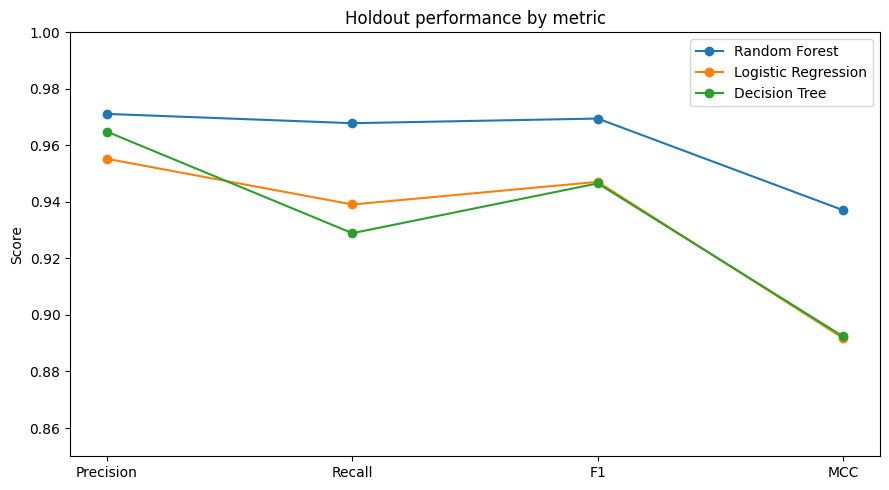

In [17]:
metric_plot = holdout_results[["Precision", "Recall", "F1", "MCC"]].T
plt.figure(figsize=(9, 5))
for model_name in metric_plot.columns:
    plt.plot(metric_plot.index, metric_plot[model_name], marker="o", label=model_name)
plt.ylim(0.85, 1.0)
plt.ylabel("Score")
plt.title("Holdout performance by metric")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "model_metric_comparison.png", dpi=180)
plt.show()

### Confusion matrix, ROC, and precision-recall curves

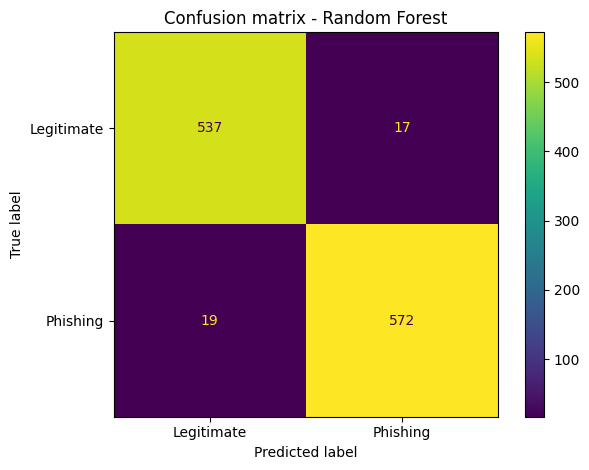

In [18]:
best_name = holdout_results.index[0]
best_model = fitted_models[best_name]
best_prediction = best_model.predict(X_test)
ConfusionMatrixDisplay.from_predictions(
    y_test, best_prediction, labels=[0, 1], display_labels=["Legitimate", "Phishing"], values_format="d"
)
plt.title(f"Confusion matrix - {best_name}")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "confusion_matrix_best_model.png", dpi=180)
plt.show()

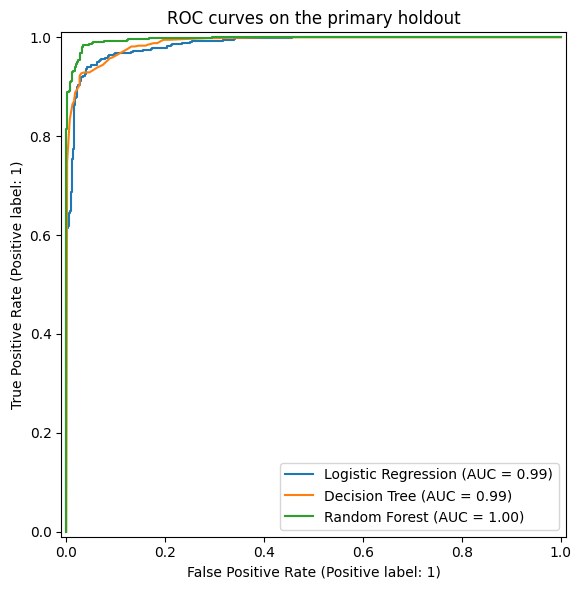

In [19]:
plt.figure(figsize=(7, 6))
axis = plt.gca()
for name, model in fitted_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=axis)
plt.title("ROC curves on the primary holdout")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "roc_curves.png", dpi=180)
plt.show()

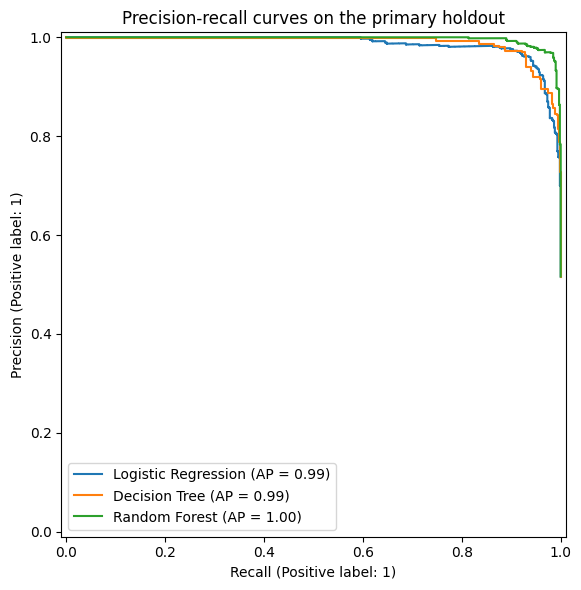

In [20]:
plt.figure(figsize=(7, 6))
axis = plt.gca()
for name, model in fitted_models.items():
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, name=name, ax=axis)
plt.title("Precision-recall curves on the primary holdout")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "precision_recall_curves.png", dpi=180)
plt.show()

## 9. Five-fold cross-validation

A fixed stratified 5-fold cross-validation estimates performance variability. This is more informative than a single split, although it still cannot replace chronological or external validation.

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}
cv_rows = []
for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=1)
    row = {"Model": name}
    for metric in scoring:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()
    cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows).set_index("Model")
display(cv_results.style.format("{:.4f}"))
cv_results.to_csv(RESULT_DIR / "cross_validation_results.csv")

,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std
Model,,,,,,,,,,,,,,
Logistic Regression,0.9287,0.0057,0.9288,0.0058,0.9367,0.0090,0.9245,0.0083,0.9305,0.0055,0.9805,0.0027,0.9827,0.0027
Decision Tree,0.9360,0.0055,0.9363,0.0053,0.9462,0.0023,0.9289,0.0121,0.9375,0.0058,0.9818,0.0042,0.9811,0.0046
Random Forest,0.9596,0.0070,0.9598,0.0069,0.9677,0.0059,0.9536,0.0120,0.9606,0.0070,0.9934,0.0020,0.9941,0.0017


## 10. Redundancy and feature-selection sensitivity

The redundancy procedure is learned on the training set only. For every pair with \(|\rho_s|\ge 0.80\), mutual information with the target is compared and the weaker member is removed. Mutual information captures general statistical dependence rather than only monotonic dependence.

In [22]:
training_correlation = X_train.corr(method="spearman")
training_mi = pd.Series(
    mutual_info_classif(X_train, y_train, discrete_features=True, random_state=RANDOM_STATE),
    index=FEATURE_NAMES,
)
redundant_rows = []
features_to_drop = set()
for left_index, left in enumerate(FEATURE_NAMES):
    for right in FEATURE_NAMES[left_index + 1:]:
        rho = training_correlation.loc[left, right]
        if abs(rho) >= 0.80:
            dropped = left if training_mi[left] < training_mi[right] else right
            features_to_drop.add(dropped)
            redundant_rows.append({
                "feature_1": left, "feature_2": right, "rho": rho,
                "MI_feature_1": training_mi[left], "MI_feature_2": training_mi[right],
                "dropped": dropped,
            })
redundant_pairs = pd.DataFrame(redundant_rows)
kept_features = [feature for feature in FEATURE_NAMES if feature not in features_to_drop]
display(redundant_pairs.style.format({"rho": "{:.3f}", "MI_feature_1": "{:.4f}", "MI_feature_2": "{:.4f}"}))
print("Dropped features:", sorted(features_to_drop))

,feature_1,feature_2,rho,MI_feature_1,MI_feature_2,dropped
0,Shortining_Service,double_slash_redirecting,0.819,0.0025,0.0005,double_slash_redirecting
1,Favicon,port,0.821,0.0004,0.0001,port
2,Favicon,popUpWidnow,0.937,0.0004,0.0003,popUpWidnow


Dropped features: ['double_slash_redirecting', 'popUpWidnow', 'port']


In [23]:
reduced_forest = RandomForestClassifier(
    n_estimators=200, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=1
).fit(X_train[kept_features], y_train)

redundancy_comparison = pd.DataFrame([
    {"Feature set": "All 30 features", **evaluate_classifier(best_model, X_test, y_test)},
    {"Feature set": f"Reduced ({len(kept_features)} features)", **evaluate_classifier(reduced_forest, X_test[kept_features], y_test)},
]).set_index("Feature set")
display(redundancy_comparison[["Accuracy", "Precision", "Recall", "F1", "MCC", "ROC-AUC", "PR-AUC"]].style.format("{:.4f}"))
redundancy_comparison.to_csv(RESULT_DIR / "redundancy_sensitivity.csv")

,Accuracy,Precision,Recall,F1,MCC,ROC-AUC,PR-AUC
Feature set,,,,,,,
All 30 features,0.9686,0.9711,0.9679,0.9695,0.9371,0.9963,0.9967
Reduced (27 features),0.9738,0.9746,0.9746,0.9746,0.9475,0.9964,0.9967


The reduced model does not lose performance in this split. This does not prove that the dropped fields are universally useless; it shows that their information is largely duplicated here and that removing them can simplify explanations and data collection.

## 11. Permutation importance

Permutation importance measures how much holdout F1 decreases when one feature is shuffled. Unlike impurity-based tree importance, it is evaluated on unseen data, though correlated predictors can still share importance.

In [24]:
permutation = permutation_importance(
    best_model, X_test, y_test, n_repeats=10,
    scoring="f1", random_state=RANDOM_STATE, n_jobs=1,
)
importance = pd.DataFrame({
    "feature": FEATURE_NAMES,
    "importance_mean": permutation.importances_mean,
    "importance_std": permutation.importances_std,
}).sort_values("importance_mean", ascending=False)
display(importance.head(15).style.format({"importance_mean": "{:.4f}", "importance_std": "{:.4f}"}))
importance.to_csv(RESULT_DIR / "permutation_importance.csv", index=False)

,feature,importance_mean,importance_std
7,SSLfinal_State,0.1242,0.0076
13,URL_of_Anchor,0.1150,0.0072
5,Prefix_Suffix,0.0325,0.0038
14,Links_in_tags,0.0164,0.0026
25,web_traffic,0.0094,0.0018
15,SFH,0.0090,0.0015
6,having_Sub_Domain,0.0077,0.0024
0,having_IP_Address,0.0070,0.0016
28,Links_pointing_to_page,0.0044,0.0018
12,Request_URL,0.0036,0.0012


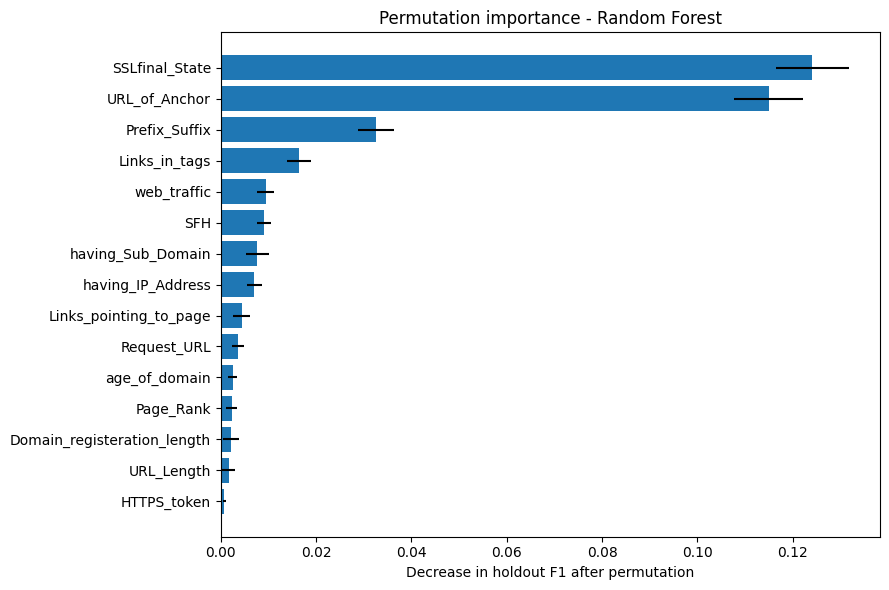

In [25]:
plt.figure(figsize=(9, 6))
top_importance = importance.head(15).sort_values("importance_mean")
plt.barh(top_importance["feature"], top_importance["importance_mean"], xerr=top_importance["importance_std"])
plt.xlabel("Decrease in holdout F1 after permutation")
plt.title(f"Permutation importance - {best_name}")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "permutation_importance.png", dpi=180)
plt.show()

## 12. Error analysis and threshold trade-off

- **False positive:** a legitimate site is flagged as phishing. This can block business activity and create alert fatigue.
- **False negative:** a phishing site is treated as legitimate. This can expose credentials or financial data and is usually the more serious error.

Because the dataset contains only engineered vectors, failures cannot be inspected as raw webpages. We can still compare the feature profiles of false negatives with correctly detected phishing pages, and false positives with correctly detected legitimate pages.

In [26]:
best_probability = positive_probability(best_model, X_test)
error_table = X_test.copy()
error_table["true_phishing"] = y_test.to_numpy()
error_table["predicted_phishing"] = best_prediction
error_table["phishing_probability"] = best_probability
error_table["error_type"] = np.select(
    [
        (error_table["true_phishing"] == 1) & (error_table["predicted_phishing"] == 0),
        (error_table["true_phishing"] == 0) & (error_table["predicted_phishing"] == 1),
    ],
    ["False Negative", "False Positive"],
    default="Correct",
)
print(error_table["error_type"].value_counts())
error_table.to_csv(RESULT_DIR / "holdout_predictions_and_errors.csv", index=False)

# Concrete examples: the most confident mistakes under the default 0.5 threshold.
example_columns = [
    "error_type", "phishing_probability", "SSLfinal_State", "URL_of_Anchor",
    "Prefix_Suffix", "web_traffic", "having_Sub_Domain", "true_phishing", "predicted_phishing"
]
most_confident_fn = (
    error_table[error_table["error_type"] == "False Negative"]
    .sort_values("phishing_probability", ascending=True)
    .head(3)
)
most_confident_fp = (
    error_table[error_table["error_type"] == "False Positive"]
    .sort_values("phishing_probability", ascending=False)
    .head(3)
)
error_examples = pd.concat([most_confident_fn, most_confident_fp])[example_columns]
print("Concrete high-confidence error examples (feature vectors, because raw URLs are unavailable):")
display(error_examples.style.format({"phishing_probability": "{:.4f}"}))
error_examples.to_csv(RESULT_DIR / "error_examples.csv", index=False)


error_type
Correct           1109
False Negative      19
False Positive      17
Name: count, dtype: int64
Concrete high-confidence error examples (feature vectors, because raw URLs are unavailable):


,error_type,phishing_probability,SSLfinal_State,URL_of_Anchor,Prefix_Suffix,web_traffic,having_Sub_Domain,true_phishing,predicted_phishing
4113,False Negative,0.0963,1,0,-1,1,0,1,0
2149,False Negative,0.1773,1,0,-1,0,1,1,0
5505,False Negative,0.2258,1,0,-1,1,0,1,0
3759,False Positive,0.8220,-1,0,-1,0,0,0,1
3756,False Positive,0.7575,-1,0,-1,-1,0,0,1
957,False Positive,0.7570,-1,0,-1,1,-1,0,1


In [27]:
false_negatives = error_table[error_table["error_type"] == "False Negative"]
true_positives = error_table[(error_table["true_phishing"] == 1) & (error_table["predicted_phishing"] == 1)]
false_positives = error_table[error_table["error_type"] == "False Positive"]
true_negatives = error_table[(error_table["true_phishing"] == 0) & (error_table["predicted_phishing"] == 0)]

fn_patterns = pd.DataFrame({
    "FN_mean": false_negatives[FEATURE_NAMES].mean(),
    "TP_mean": true_positives[FEATURE_NAMES].mean(),
})
fn_patterns["difference"] = fn_patterns["FN_mean"] - fn_patterns["TP_mean"]
fn_patterns["absolute_difference"] = fn_patterns["difference"].abs()

fp_patterns = pd.DataFrame({
    "FP_mean": false_positives[FEATURE_NAMES].mean(),
    "TN_mean": true_negatives[FEATURE_NAMES].mean(),
})
fp_patterns["difference"] = fp_patterns["FP_mean"] - fp_patterns["TN_mean"]
fp_patterns["absolute_difference"] = fp_patterns["difference"].abs()

print("Largest false-negative profile differences:")
display(fn_patterns.sort_values("absolute_difference", ascending=False).head(10).style.format("{:.3f}"))
print("Largest false-positive profile differences:")
display(fp_patterns.sort_values("absolute_difference", ascending=False).head(10).style.format("{:.3f}"))

Largest false-negative profile differences:


,FN_mean,TP_mean,difference,absolute_difference
SSLfinal_State,0.789,-0.559,1.349,1.349
Domain_registeration_length,-0.789,-0.070,-0.720,0.720
URL_of_Anchor,0.000,-0.654,0.654,0.654
age_of_domain,0.579,0.010,0.568,0.568
URL_Length,-0.158,-0.673,0.515,0.515
having_Sub_Domain,0.316,-0.178,0.494,0.494
Request_URL,0.263,-0.140,0.403,0.403
Links_in_tags,0.000,-0.402,0.402,0.402
web_traffic,0.368,-0.014,0.382,0.382
Statistical_report,0.895,0.612,0.283,0.283


Largest false-positive profile differences:


,FP_mean,TN_mean,difference,absolute_difference
SSLfinal_State,-0.529,0.883,-1.412,1.412
age_of_domain,-0.529,0.061,-0.591,0.591
Prefix_Suffix,-1.000,-0.456,-0.544,0.544
URL_Length,-1.000,-0.533,-0.467,0.467
Domain_registeration_length,-0.059,-0.512,0.453,0.453
SFH,-0.765,-0.333,-0.431,0.431
having_At_Symbol,1.000,0.575,0.425,0.425
Submitting_to_email,1.000,0.575,0.425,0.425
Abnormal_URL,1.000,0.594,0.406,0.406
web_traffic,0.118,0.503,-0.385,0.385


False negatives tend to look legitimate on the strongest predictors, especially SSL state and anchor behavior. False positives show the reverse pattern. This indicates that the model is not failing randomly; it fails on vectors whose strongest indicators conflict with the ground-truth label.

### Threshold analysis

The default probability threshold is 0.5. Lowering it increases recall and reduces false negatives at the cost of more false positives. The correct threshold should be selected using organization-specific incident costs, not by maximizing accuracy blindly.

In [28]:
threshold_rows = []
for threshold in [0.25, 0.35, 0.40, 0.50, 0.60, 0.70, 0.75]:
    threshold_prediction = (best_probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, threshold_prediction, labels=[0, 1]).ravel()
    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_test, threshold_prediction),
        "recall": recall_score(y_test, threshold_prediction),
        "F1": f1_score(y_test, threshold_prediction),
        "F2": fbeta_score(y_test, threshold_prediction, beta=2),
        "FP": fp, "FN": fn, "TP": tp, "TN": tn,
    })
threshold_results = pd.DataFrame(threshold_rows)
display(threshold_results.style.format({
    "threshold": "{:.2f}", "precision": "{:.4f}", "recall": "{:.4f}", "F1": "{:.4f}", "F2": "{:.4f}",
}))
threshold_results.to_csv(RESULT_DIR / "threshold_sensitivity.csv", index=False)

,threshold,precision,recall,F1,F2,FP,FN,TP,TN
0,0.25,0.9071,0.9915,0.9475,0.9734,60,5,586,494
1,0.35,0.9511,0.9882,0.9693,0.9805,30,7,584,524
2,0.40,0.9636,0.9848,0.9741,0.9805,22,9,582,532
3,0.50,0.9711,0.9679,0.9695,0.9685,17,19,572,537
4,0.60,0.9806,0.9391,0.9594,0.9471,11,36,555,543
5,0.70,0.9872,0.9137,0.9490,0.9275,7,51,540,547
6,0.75,0.9925,0.8968,0.9422,0.9144,4,61,530,550


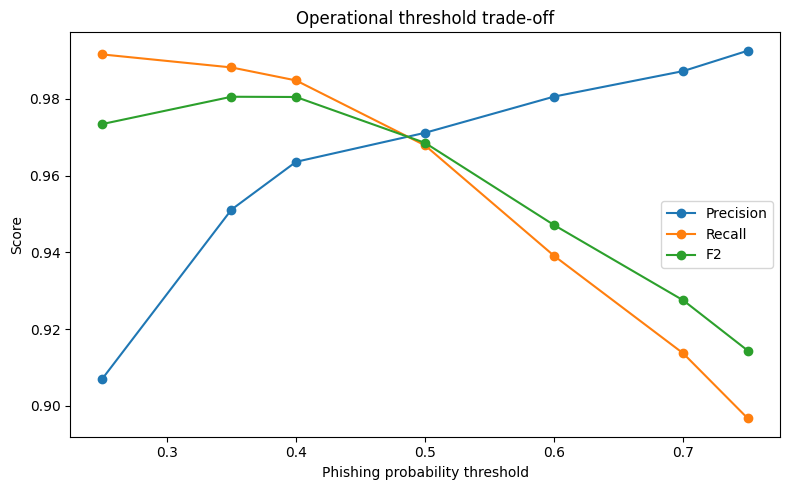

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_results["threshold"], threshold_results["precision"], marker="o", label="Precision")
plt.plot(threshold_results["threshold"], threshold_results["recall"], marker="o", label="Recall")
plt.plot(threshold_results["threshold"], threshold_results["F2"], marker="o", label="F2")
plt.xlabel("Phishing probability threshold")
plt.ylabel("Score")
plt.title("Operational threshold trade-off")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "threshold_tradeoff.png", dpi=180)
plt.show()

## 13. Critical conclusions / Summing It Up

- **Problem:** classify phishing and legitimate websites from 30 pre-engineered indicators.
- **Selected source:** Nicolas Papernot's Medium tutorial and its GitHub implementation.
- **Dataset:** the UCI Phishing Websites table currently contains 11,055 rows, not the 2,456 claimed by the tutorial.
- **Methodology:** reproduce the original fixed row-order split, then perform duplicate-aware cleaning, stratified holdout testing, 5-fold cross-validation, three-model comparison, redundancy analysis, permutation importance, and threshold-based error analysis.
- **Reproduction finding:** approximately 90.5% accuracy is obtained only under the current file's unintended 9,055-row test behavior. The documented 456-row test does not reproduce that value.
- **Label finding:** the tutorial's prose reverses the UCI class meanings. Correct phishing-positive metrics require treating `Result = -1` as phishing.
- **Model finding:** Random Forest performs best on the primary cleaned experiment, but the difference between static benchmark performance and real deployment remains large.
- **Most important insight:** evaluation design and data provenance matter more than reporting one high accuracy number. Duplicate structure, contradictory labels, target semantics, and the absence of time or campaign identifiers materially affect the validity of conclusions.
- **Recommendation:** do not deploy the tutorial model unchanged. It is useful as an introductory exercise and as a baseline for a redesigned study using recent time-stamped URLs, transparent feature extraction, external validation, campaign-aware splits, calibration, and adversarial robustness testing.